событий: 1184


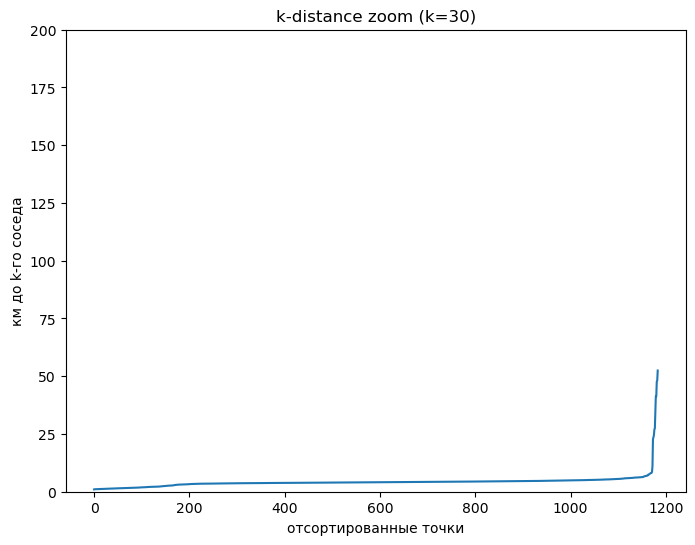

p50: 4.1 км
p75: 4.6 км
p90: 5.2 км
p95: 5.9 км
p97: 6.3 км
p98: 6.9 км
p99: 9.0 км


DBSCAN: min_samples:   0%|          | 0/1 [00:00<?, ?it/s]

eps_km (k=4):   0%|          | 0/6 [00:00<?, ?it/s]

,k,eps_km,clusters,noise_ratio,coverage,score
5,4,4.775307,3,0.009291,0.990709,0.831742
4,4,4.000000,3,0.010135,0.989865,0.831067
3,4,2.899513,3,0.013514,0.986486,0.828364
2,4,2.635932,3,0.015203,0.984797,0.827013
1,4,2.283007,3,0.018581,0.981419,0.824310
0,4,1.929401,4,0.038851,0.961149,0.814399


Лучшее DBSCAN: {'k': 4, 'eps_km': 4.775306525515402, 'clusters': 3, 'noise_ratio': 0.009290540540540541, 'score': 0.8317422688709688}


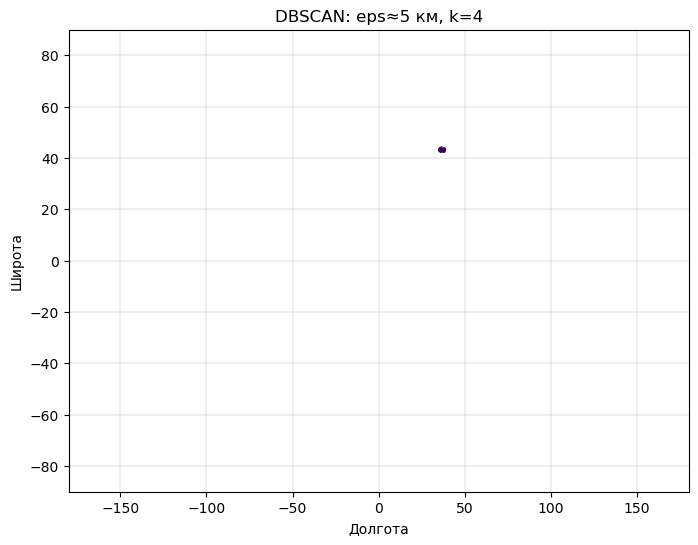

/tmp/ipykernel_55650/2504995607.py:158: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(unique_clusters))


Карта сохранена: /home/vladislav/Рабочий стол/mzsk_1_1/3 semestr/Нейронные сети и машинное обучение  оц.Акишин Б.А./program_console/earthquakes_map_dbscan_test.html


In [ ]:
# ================= Earthquakes → DBSCAN (haversine) + интерактивная карта =================
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

try:
    # чтобы display() работал и в ноутбуке, и молча игнорировался в .py
    from IPython.display import display
except Exception:
    def display(*args, **kwargs): pass

plt.rcParams["figure.figsize"] = (8, 6)
EARTH_RADIUS_KM = 6371.0088
np.random.seed(7)

# --- путь и имена колонок ---
CSV_PATH = "/home/vladislav/Рабочий стол/mzsk_1_1/3 semestr/Нейронные сети и машинное обучение  оц.Акишин Б.А./program_console/dbscan_two_moons_2or3.csv"   # <-- поменяй при необходимости
LAT_COL  = "latitude"
LON_COL  = "longitude"
MAG_COL  = "magnitudo"
MIN_MAG  = 5.0  # оставим ощутимые события

assert os.path.exists(CSV_PATH), f"Файл не найден: {CSV_PATH}"

# 1) загрузка и чистка
df = pd.read_csv(CSV_PATH, low_memory=False)
df = df[[LAT_COL, LON_COL] + ([MAG_COL] if MAG_COL in df.columns else [])].dropna()
df = df[(df[LAT_COL].between(-90, 90)) & (df[LON_COL].between(-180, 180))]
if MAG_COL in df.columns and MIN_MAG is not None:
    df = df[df[MAG_COL] >= float(MIN_MAG)]
df = df.reset_index(drop=True)
print("событий:", len(df))

coords_deg = df[[LAT_COL, LON_COL]].to_numpy(dtype="float64")
coords_rad = np.radians(coords_deg)  # haversine ждёт радианы

# 2) k-distance plot (наглядный «локоть»)
def k_distance_plot(coords_rad, k=30, sample=50_000, y_max=200):
    if len(coords_rad) == 0:
        print("Нет точек для k-distance plot."); return
    idx = np.random.choice(len(coords_rad), size=min(sample, len(coords_rad)), replace=False)
    nn = NearestNeighbors(n_neighbors=k, metric="haversine", algorithm="ball_tree").fit(coords_rad[idx])
    dists, _ = nn.kneighbors(coords_rad[idx])
    kth_km = np.sort(dists[:, -1]) * EARTH_RADIUS_KM
    plt.figure(); plt.plot(kth_km);
    if y_max: plt.ylim(0, y_max)
    plt.title(f"k-distance zoom (k={k})"); plt.xlabel("отсортированные точки"); plt.ylabel("км до k-го соседа")
    plt.show()
    # полезные перцентили
    for p in [50, 75, 90, 95, 97, 98, 99]:
        print(f"p{p}: {np.percentile(kth_km, p):.1f} км")

k_distance_plot(coords_rad, k=30, y_max=200)

# 3) DBSCAN (haversine) + грид: улучшенный критерий выбора "best"
def run_dbscan(coords_rad, eps_km, k):
    eps_rad = eps_km / EARTH_RADIUS_KM
    labels = DBSCAN(eps=eps_rad, min_samples=k, metric="haversine", algorithm="ball_tree").fit_predict(coords_rad)
    ncl = len(set(labels)) - (1 if -1 in labels else 0)
    noise = float((labels == -1).mean())
    return labels, ncl, noise

def grid_dbscan(coords_rad,
                eps_km_list=(5,10,25,50,75,100),
                k_list=(20,30,40,60),
                max_noise=0.30,           # допустимая доля шума
                coverage_weight=0.80,     # вес покрытия vs число кластеров
                prefer_larger_eps=True):   # при равном score предпочитаем бОльший eps
    rows, best = [], None
    n_points = len(coords_rad)
    denom = np.log1p(n_points) if n_points > 0 else 1.0

    for k in tqdm(k_list, desc="DBSCAN: min_samples"):
        # авто-кандидаты по k-distance
        nn = NearestNeighbors(n_neighbors=k, metric="haversine", algorithm="ball_tree").fit(coords_rad)
        kth_km = nn.kneighbors(coords_rad, return_distance=True)[0][:, -1] * EARTH_RADIUS_KM
        eps_auto = np.percentile(kth_km, [90,95,97,98,99]).tolist()
        eps_candidates = sorted(set([*eps_km_list, *eps_auto]))

        for eps in tqdm(eps_candidates, leave=False, desc=f"eps_km (k={k})"):
            lab, ncl, noise = run_dbscan(coords_rad, eps, k)
            coverage = 1.0 - noise
            cluster_term = np.log1p(ncl) / denom
            score = coverage_weight * coverage + (1.0 - coverage_weight) * cluster_term
            if noise > max_noise:
                score = -1.0

            rows.append({
                "k": int(k), "eps_km": float(eps),
                "clusters": int(ncl), "noise_ratio": float(noise),
                "coverage": float(coverage), "score": float(score)
            })

            cand = {"score": float(score), "k": int(k), "eps_km": float(eps),
                    "labels": lab, "clusters": int(ncl), "noise_ratio": float(noise)}
            if best is None:
                best = cand
            else:
                better = cand["score"] > best["score"]
                tie = np.isclose(cand["score"], best["score"])
                if better or (tie and prefer_larger_eps and cand["eps_km"] > best["eps_km"]):
                    best = cand

    df_runs = pd.DataFrame(rows).sort_values(["score","coverage","clusters"], ascending=[False, False, False])
    return df_runs, best

# исходя из перцентилей для k=30: ограничим диапазон eps
df_db, best_db = grid_dbscan(
    coords_rad,
    eps_km_list=(4,),
    k_list=(4,),
    max_noise=0.10,
    coverage_weight=0.80,
    prefer_larger_eps=True
    # eps_km_list=(150, 180, 200, 220, 240, 260),
    # k_list=(30,),
    # max_noise=0.30,
)
display(df_db.head(10))
print("Лучшее DBSCAN:", {k:best_db[k] for k in ["k","eps_km","clusters","noise_ratio","score"]})

# 4) Статическая «карта» кластеров
def plot_clusters(lonlat_deg, labels, title):
    lon = lonlat_deg[:,1]; lat = lonlat_deg[:,0]
    plt.figure()
    plt.scatter(lon, lat, s=4, c=labels, alpha=0.8)
    plt.title(title); plt.xlabel("Долгота"); plt.ylabel("Широта")
    plt.xlim(-180, 180); plt.ylim(-90, 90); plt.grid(True, linewidth=0.3); plt.show()

plot_clusters(coords_deg, best_db["labels"], f"DBSCAN: eps≈{best_db['eps_km']:.0f} км, k={best_db['k']}")

# 5) Интерактивная карта (folium): тепловая карта + цветные кластеры + центроиды
try:
    import folium
    from folium.plugins import HeatMap
    from collections import defaultdict
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    import webbrowser
    from pathlib import Path

    # центроиды кластера по среднему lat/lon
    def cluster_centroids(lonlat_deg, labels):
        from collections import defaultdict
        buckets = defaultdict(list)
        for (lat, lon), lab in zip(lonlat_deg, labels):
            if lab == -1:
                continue
            buckets[int(lab)].append((lat, lon))
        rows = []
        for lab, pts in buckets.items():
            a = np.array(pts, dtype="float64")
            rows.append({"cluster": lab, "count": len(a), "lat": a[:,0].mean(), "lon": a[:,1].mean()})
        return pd.DataFrame(rows).sort_values("count", ascending=False)

    def add_clusters_to_map(map_obj, coords_all, labels, layer_prefix="DBSCAN"):
        unique_clusters = sorted(set(labels) - {-1})
        if len(unique_clusters) == 0:
            return
        cmap = cm.get_cmap("tab20", len(unique_clusters))
        cluster2color = {cl: mcolors.to_hex(cmap(i)) for i, cl in enumerate(unique_clusters)}

        centroids_df = cluster_centroids(coords_all, labels)
        centroids_layer = folium.FeatureGroup(name=f"{layer_prefix} centroids", show=True)
        for _, r in centroids_df.iterrows():
            folium.CircleMarker(
                location=[r.lat, r.lon],
                radius=max(4, min(15, r["count"]**0.3)),
                popup=f"{layer_prefix} cluster {int(r.cluster)} (n={int(r['count'])})",
                color="#000000", weight=1, fill=True, fill_color="#ffffff", fill_opacity=0.9
            ).add_to(centroids_layer)
        centroids_layer.add_to(map_obj)

        for cl in unique_clusters:
            mask = (labels == cl)
            pts = coords_all[mask]
            max_points = 1000
            if len(pts) > max_points:
                pts = pts[np.random.choice(len(pts), max_points, replace=False)]
            color = cluster2color[cl]
            cluster_layer = folium.FeatureGroup(name=f"{layer_prefix} cluster {cl} (pts~{mask.sum()})", show=False)
            for (lat, lon) in pts:
                folium.CircleMarker(location=[lat, lon], radius=2, color=color,
                                    weight=1, fill=True, fill_color=color, fill_opacity=0.6).add_to(cluster_layer)
            cluster_layer.add_to(map_obj)

    HEAT_SAMPLE = min(200_000, len(coords_deg))
    if HEAT_SAMPLE > 0:
        idx = np.random.choice(len(coords_deg), HEAT_SAMPLE, replace=False)
        heat_points = coords_deg[idx].tolist()
    else:
        heat_points = []

    m = folium.Map(location=[0, 0], zoom_start=2, tiles="CartoDB positron")

    if heat_points:
        HeatMap(heat_points, radius=4, blur=3, min_opacity=0.2, max_zoom=6).add_to(m)

    add_clusters_to_map(map_obj=m, coords_all=coords_deg, labels=best_db["labels"], layer_prefix="DBSCAN")
    folium.LayerControl(collapsed=False).add_to(m)

    # для ноутбука
    display(m)

    # и для .py — сохраним и попробуем открыть
    # out_html = Path("earthquakes_map_dbscan_test.html").resolve()
    # m.save(str(out_html))
    # print(f"Карта сохранена: {out_html}")
    # try:
    #     webbrowser.open(out_html.as_uri())
    # except Exception:
    #     pass

except Exception as e:
    print("Интерактивная карта пропущена (pip install folium). Причина:", e)
